Запуск экспериментов...


tight: 100%|██████████| 50/50 [15:24<00:00, 18.50s/it] 


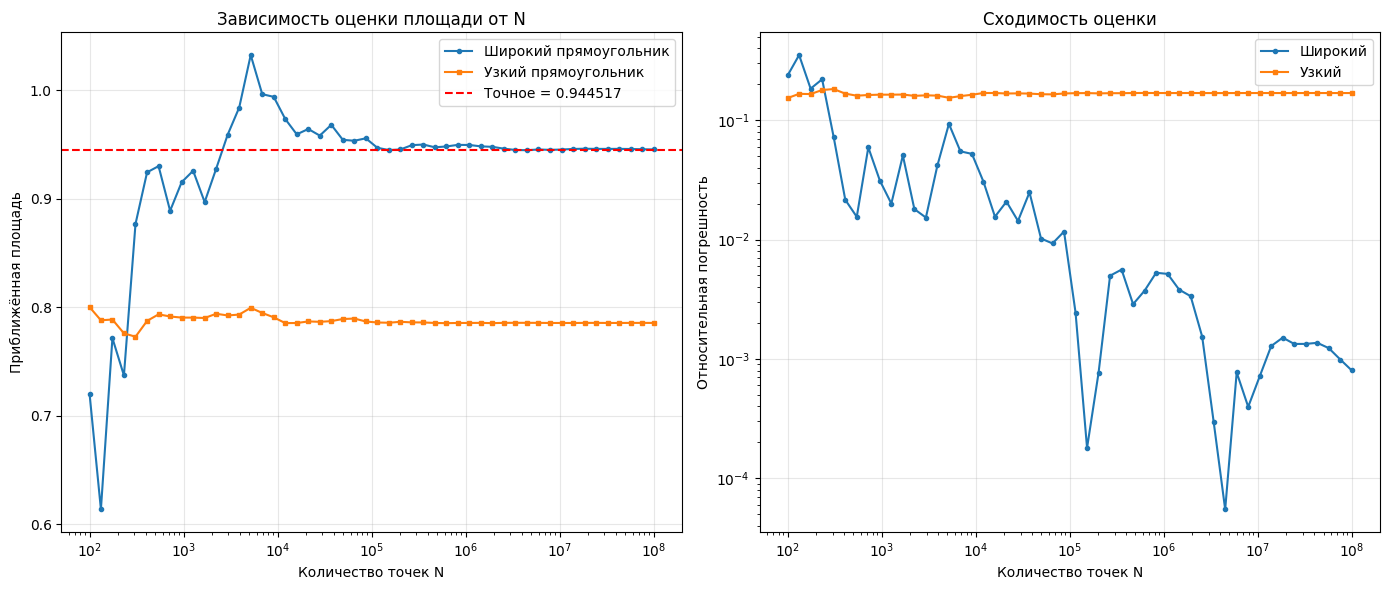

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm

# Точные значения для конкретной задачи из условия
TRUE_AREA = 0.25 * math.pi + 1.25 * math.asin(0.8) - 1  # ≈ 0.443802...

# Три круга из условия
circles = [
    (1.0, 1.0, 1.0),
    (1.5, 2.0, math.sqrt(5)/2),
    (2.0, 1.5, math.sqrt(5)/2)
]

def is_inside(x, y, circles):
    for cx, cy, r in circles:
        if (x - cx)**2 + (y - cy)**2 > r**2 + 1e-12:
            return False
    return True

def monte_carlo_area(N, bbox, seed=42):
    np.random.seed(seed)
    min_x, max_x, min_y, max_y = bbox
    points = np.random.uniform(low=[min_x, min_y], high=[max_x, max_y], size=(N, 2))
    inside = np.array([is_inside(x, y, circles) for x, y in points])
    M = np.sum(inside)
    rect_area = (max_x - min_x) * (max_y - min_y)
    return (M / N) * rect_area

# Определение двух прямоугольников
wide_bbox = (0.0, 3.0, 0.0, 3.0)      # Широкий
tight_bbox = (1.0, 2.0, 1.0, 2.0)     # Узкий (примерно вокруг пересечения)

Ns = np.logspace(2, 8, 50).astype(int)  # от 100 до 100e6
Ns = np.unique(Ns)

results = {
    'wide': {'area': [], 'rel_err': []},
    'tight': {'area': [], 'rel_err': []}
}

print("Запуск экспериментов...")
for bbox_name, bbox in [('wide', wide_bbox), ('tight', tight_bbox)]:
    for N in tqdm(Ns, desc=bbox_name):
        est = monte_carlo_area(N, bbox)
        rel_err = abs(est - TRUE_AREA) / TRUE_AREA
        results[bbox_name]['area'].append(est)
        results[bbox_name]['rel_err'].append(rel_err)

# Графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Приближённая площадь
ax1.plot(Ns, results['wide']['area'], label='Широкий прямоугольник', marker='o', markersize=3)
ax1.plot(Ns, results['tight']['area'], label='Узкий прямоугольник', marker='s', markersize=3)
ax1.axhline(TRUE_AREA, color='red', linestyle='--', label=f'Точное = {TRUE_AREA:.6f}')
ax1.set_xscale('log')
ax1.set_xlabel('Количество точек N')
ax1.set_ylabel('Приближённая площадь')
ax1.set_title('Зависимость оценки площади от N')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Относительная погрешность
ax2.plot(Ns, results['wide']['rel_err'], label='Широкий', marker='o', markersize=3)
ax2.plot(Ns, results['tight']['rel_err'], label='Узкий', marker='s', markersize=3)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Количество точек N')
ax2.set_ylabel('Относительная погрешность')
ax2.set_title('Сходимость оценки')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

data = []
for i, N in enumerate(Ns):
    data.append({
        'N': N,
        'wide_area': results['wide']['area'][i],
        'wide_rel_err': results['wide']['rel_err'][i],
        'tight_area': results['tight']['area'][i],
        'tight_rel_err': results['tight']['rel_err'][i]
    })

df = pd.DataFrame(data)
df.to_csv('raw_data.csv', index=False)
print("Сохранено в raw_data.csv")

Сохранено в raw_data.csv


In [3]:
df

,N,wide_area,wide_rel_err,tight_area,tight_rel_err
0,100,0.720000,0.237706,0.800000,0.153006
1,132,0.613636,0.350317,0.787879,0.165840
2,175,0.771429,0.183256,0.788571,0.165106
3,232,0.737069,0.219634,0.775862,0.178562
4,308,0.876623,0.071882,0.772727,0.181881
5,409,0.924205,0.021505,0.787286,0.166467
6,542,0.929889,0.015487,0.793358,0.160039
7,719,0.888734,0.059060,0.791377,0.162136
8,954,0.915094,0.031151,0.790356,0.163217
9,1264,0.925633,0.019994,0.790348,0.163225


In [4]:
import math
S = 0.25 * math.pi + 1.25 * math.asin(0.8) - 1
print(S)

0.9445171858994637
